In [1]:
# Iris Flower Classification using Machine Learning

## CodeAlpha Data Science Internship

### Project Objective

#The objective of this project is to classify Iris flowers into different species using Machine Learning. The classification is based on flower measurements such as sepal length, sepal width, petal length, and petal width.

#The K-Nearest Neighbors (KNN) algorithm is used to build the classification model and evaluate its performance.

In [2]:
## Importing Required Libraries

#The following libraries are used for data manipulation, visualization, and machine learning.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
## Loading the Dataset
#The Iris dataset is loaded into a Pandas DataFrame for analysis.
df = pd.read_csv("Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [7]:
## Dataset Overview
#Understanding the structure and characteristics of the dataset.
print("Shape of Dataset:", df.shape)
df.info()
df.describe()
#The dataset contains 150 flower samples and several numerical features representing flower measurements.

Shape of Dataset: (150, 6)
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [9]:
## Missing Value Analysis
#Checking whether the dataset contains missing values.
df.isnull().sum()
#No missing values were found in the dataset.

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


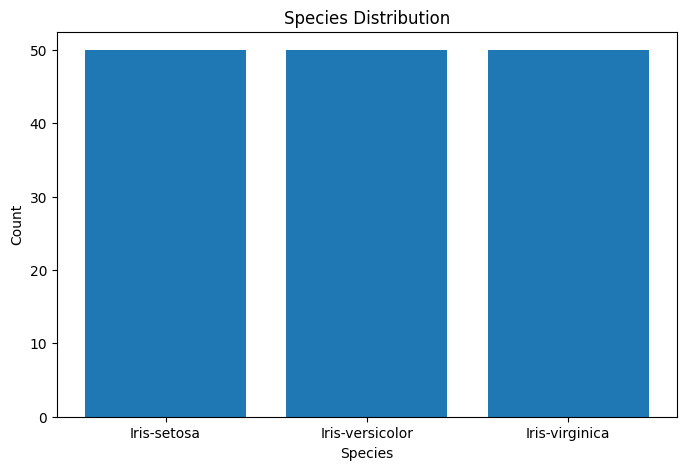

In [12]:
## Species Distribution
#Analyzing the number of flowers belonging to each species.
species_count = df['Species'].value_counts()
print(species_count)
plt.figure(figsize=(8,5))

plt.bar(species_count.index,
        species_count.values)

plt.title("Species Distribution")
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()
#The dataset is balanced with 50 samples belonging to each species.

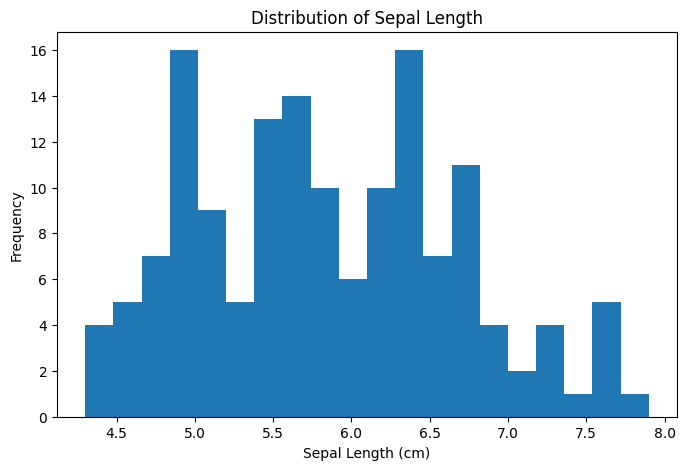

In [14]:
## Distribution of Sepal Length
plt.figure(figsize=(8,5))

plt.hist(df['SepalLengthCm'],
         bins=20)

plt.title("Distribution of Sepal Length")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Frequency")

plt.show()
#Most flowers have sepal lengths between 5 cm and 7 cm.

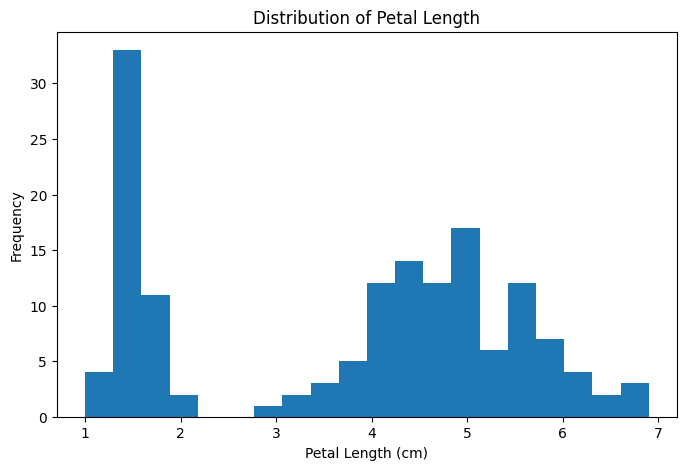

In [15]:
## Distribution of Petal Length
plt.figure(figsize=(8,5))

plt.hist(df['PetalLengthCm'],
         bins=20)

plt.title("Distribution of Petal Length")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Frequency")

plt.show()
#Petal length shows noticeable variation across flower species.

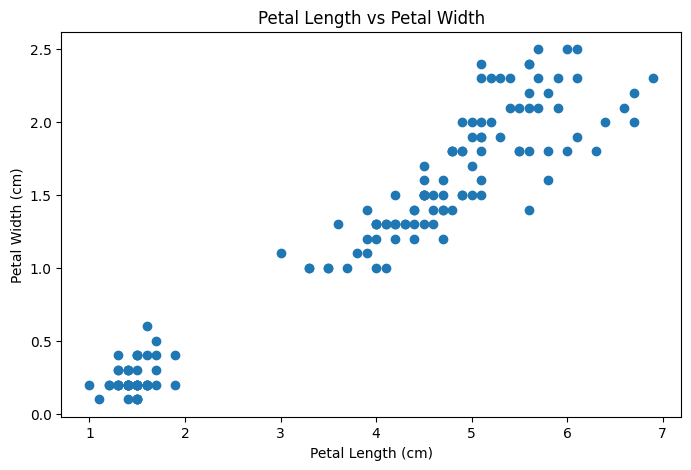

In [17]:
## Petal Length vs Petal Width
plt.figure(figsize=(8,5))

plt.scatter(
    df['PetalLengthCm'],
    df['PetalWidthCm']
)

plt.title("Petal Length vs Petal Width")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")

plt.show()
#A positive relationship exists between petal length and petal width.

In [18]:
## Feature Selection
#Selecting the input features and target variable.
X = df[['SepalLengthCm',
        'SepalWidthCm',
        'PetalLengthCm',
        'PetalWidthCm']]

y = df['Species']

In [20]:
## Splitting Dataset
#The dataset is divided into training and testing sets.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
## Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
## K-Nearest Neighbors (KNN) Model
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=3)

model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](3,)","['Iris-setosa','Iris-versicolor','Iris-virginica']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [26]:
## Making Predictions
predictions = model.predict(X_test)

print(predictions[:10])

['Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-versicolor' 'Iris-versicolor']


In [29]:
## Accuracy Evaluation
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy * 100, "%")
#The model achieved high classification accuracy, indicating strong predictive performance.

Model Accuracy: 100.0 %


In [31]:
## Predicting a New Flower Sample
sample = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=[
        'SepalLengthCm',
        'SepalWidthCm',
        'PetalLengthCm',
        'PetalWidthCm'
    ]
)

sample_scaled = scaler.transform(sample)

prediction = model.predict(sample_scaled)

print("Predicted Species:", prediction[0])



Predicted Species: Iris-setosa


In [32]:
## Key Findings

#1. The dataset contains 150 flower samples equally distributed across three species.

#2. No missing values were found in the dataset.

#3. Petal measurements are highly useful for species classification.

#4. Feature scaling improved compatibility with the KNN algorithm.

#5. The machine learning model achieved high prediction accuracy.

#6. KNN successfully classified Iris flowers based on flower measurements.

In [33]:
## Conclusion

#This project successfully implemented a machine learning classification model using the K-Nearest Neighbors algorithm. The Iris dataset was explored, visualized, and preprocessed before training the model. The resulting classifier achieved strong accuracy and demonstrated the effectiveness of machine learning in solving classification problems. The project provided practical experience with data analysis, visualization, preprocessing, model training, and evaluation using Python.